In [1]:
import torch, torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
import time
import os
import cv2
from dataPreparation import dataPrep
from imutils import paths
from sklearn.model_selection import train_test_split
from torch.nn import Module
from FCN import FCN
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW
from tqdm import tqdm
from earlyStopping import EarlyStopping

In [2]:



dataset_path = "/Users/beyzaecemerce/GitHub/thesis/drone/dataset/semantic_drone_dataset/"
image_path=dataset_path+'original_images'
masked_path = dataset_path+ 'label_images_semantic'
rgb_mask_path='/Users/beyzaecemerce/GitHub/thesis/drone/RGB_color_image_masks/RGB_color_image_masks'
TEST_SPLIT = 0.10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = True if DEVICE == "cuda" else False

In [3]:
# image = cv2.imread(image_path+"/100.jpg")
# mask=cv2.imread(masked_path+"/100.png")
# print(image.shape)
# print(mask.shape)
# figure, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 10))
# ax[0].grid(False)
# ax[1].grid(False)
# ax[0].imshow(image)
# ax[1].imshow(mask)
# ax[0].set_title("Image")
# ax[1].set_title("Original Mask")
# figure.tight_layout()
# figure.show()

In [4]:
# path=masked_path+"/001.png"
# mask=cv2.imread(path)
# print(mask.shape)
# print(np.unique(mask))
# print(mask[50,500])

# mask=np.max(mask,axis=2)
# print(mask.shape)
# print(mask[50,500])

In [5]:
# path=masked_path+"/001.png"
# mask=cv2.imread(path)
# mask=torch.from_numpy(mask)
# print(mask.shape)
# x,y=torch.max(mask,dim=2)

# print(x[50,500])
# print(y)


In [6]:
# h, w = x.shape
# target = torch.zeros(24, h, w)
# for c in range(24):
#     target[c][x == c] = 1

In [7]:
# target.shape

In [8]:
# print(target[:,50,500])

In [9]:
INIT_LR = 0.001
NUM_EPOCHS = 10
BATCH_SIZE = 8

INPUT_IMAGE_WIDTH = 6000
INPUT_IMAGE_HEIGHT = 4000

BASE_OUTPUT ="/Users/beyzaecemerce/GitHub/thesis/drone/output"

MODEL_PATH = os.path.join(BASE_OUTPUT, "MODEL2.pth")
PLOT_PATH = os.path.sep.join([BASE_OUTPUT, "Train_Test_Plot.png"])
TEST_PATHS = os.path.sep.join([BASE_OUTPUT, "test_path.txt"])

In [10]:
imagePaths = sorted(list(paths.list_images(image_path)))
maskPaths = sorted(list(paths.list_images(masked_path)))

split = train_test_split(imagePaths, maskPaths,test_size=TEST_SPLIT, random_state=42)

(trainImages, testImages) = split[:2]
(trainMasks, testMasks) = split[2:]

print("[INFO] saving testing image paths...")
f = open(TEST_PATHS, "w")
f.write("\n".join(testImages))
f.close()

[INFO] saving testing image paths...


In [11]:
input_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((512, 1024),interpolation=cv2.INTER_NEAREST),  # Resize the input image to (height=256, width=384)
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
mask_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((512, 1024)),  # Resize the mask to the same size as the input image
    transforms.ToTensor()
])

In [12]:
train = dataPrep(imagePaths=trainImages, maskPaths=trainMasks, input_transform=input_transform, mask_transform=mask_transform,n_class=24)
test = dataPrep(imagePaths=testImages, maskPaths=testMasks, input_transform=input_transform, mask_transform=mask_transform,n_class=24)


trainLoader = DataLoader(train, shuffle=False,batch_size=BATCH_SIZE, pin_memory=PIN_MEMORY,num_workers=os.cpu_count())

testLoader = DataLoader(test, shuffle=False,batch_size=BATCH_SIZE, pin_memory=PIN_MEMORY,num_workers=os.cpu_count())


In [13]:
model=FCN(24)
opt = AdamW(model.parameters(), lr=INIT_LR)
lossFunc=torch.nn.CrossEntropyLoss()
trainSteps = len(train) // BATCH_SIZE
testSteps = len(test) // BATCH_SIZE
H = {"train_loss": [], "test_loss": []}
early_stopping=EarlyStopping()

In [14]:
import torch.nn.functional as F
def pixel_accuracy(output, mask):
    with torch.no_grad():
        output = torch.argmax(F.softmax(output, dim=1), dim=1)
        mask = torch.argmax(mask, dim=1)

        correct = torch.eq(output, mask).int()
        accuracy = float(correct.sum()) / float(correct.numel())
    return accuracy

def mIoU(pred_mask, mask, smooth=1e-10, n_classes=23):
    with torch.no_grad():
        pred_mask = F.softmax(pred_mask, dim=1)
        pred_mask = torch.argmax(pred_mask, dim=1)
        mask = torch.argmax(mask, dim=1)
        pred_mask = pred_mask.contiguous().view(-1)
        mask = mask.contiguous().view(-1)

        

        iou_per_class = []
        for clas in range(0, n_classes): #loop per pixel class
            true_class = pred_mask == clas
            true_label = mask == clas

            if true_label.long().sum().item() == 0: #no exist label in this loop
                iou_per_class.append(np.nan)
            else:
                intersect = torch.logical_and(true_class, true_label).sum().float().item()
                union = torch.logical_or(true_class, true_label).sum().float().item()

                iou = (intersect + smooth) / (union +smooth)
                iou_per_class.append(iou)
        return np.nanmean(iou_per_class)

In [15]:
print("[INFO] training the network...")
startTime = time.time()
for e in tqdm(range(NUM_EPOCHS)):
  model.train()
  totalTrainLoss = 0
  totalTestLoss = 0
  iou_score = 0
  accuracy = 0

  for (i, (x, y)) in enumerate(trainLoader):
    (x, y) = (x.to(DEVICE), y.to(DEVICE))
    pred = model(x)
    loss = lossFunc(pred, y)
    #iou_score += mIoU(pred, y)
    #accuracy += pixel_accuracy(pred, y)
    loss.backward()
    opt.step()
    opt.zero_grad()
    totalTrainLoss += loss
    print("Step",i)

  with torch.no_grad():
    model.eval()
    for (x, y) in testLoader:
      (x, y) = (x.to(DEVICE), y.to(DEVICE))
      pred = model(x)
      totalTestLoss += lossFunc(pred, y)
  avgTrainLoss = totalTrainLoss / trainSteps
  avgTestLoss = totalTestLoss / testSteps
  H["train_loss"].append(avgTrainLoss.cpu().detach().numpy())
  H["test_loss"].append(avgTestLoss.cpu().detach().numpy())
  early_stopping(avgTrainLoss,avgTestLoss)
  
        
  if early_stopping.early_stop:
      print("Early stopping")
      break
  print("[INFO] EPOCH: {}/{}".format(e + 1, NUM_EPOCHS))
  print("Train loss: {:.6f}, Test loss: {:.4f}".format(avgTrainLoss, avgTestLoss))
endTime = time.time()
print("[INFO] total time taken to train the model: {:.2f}s".format(endTime - startTime))

[INFO] training the network...


  0%|          | 0/10 [00:00<?, ?it/s]

Step 0
Step 1
Step 2
Step 3
Step 4
Step 5
Step 6
Step 7
Step 8
Step 9
Step 10
Step 11
Step 12
Step 13
Step 14
Step 15
Step 16
Step 17
Step 18
Step 19
Step 20
Step 21
Step 22
Step 23
Step 24
Step 25


: 

: 

In [ ]:
plt.style.use("ggplot")
plt.figure()
plt.plot(H["train_loss"], label="train_loss")
plt.plot(H["test_loss"], label="test_loss")
plt.title("Training Loss on Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend(loc="lower left")
plt.savefig(PLOT_PATH)
torch.save(model, MODEL_PATH)

In [ ]:
from prediction import make_predictions

[INFO] loading up test image paths...
[INFO] load up model...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


tensor([[[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]])
[1]


/Users/beyzaecemerce/GitHub/thesis/prediction.py:21: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  figure.show()


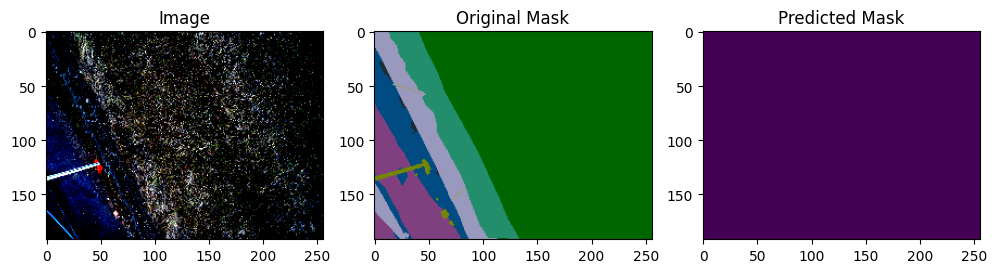

In [ ]:
print("[INFO] loading up test image paths...")
imagePaths = open(TEST_PATHS).read().strip().split("\n")
imagePaths = np.random.choice(imagePaths, size=1)
# load our model from disk and flash it to the current device
print("[INFO] load up model...")
model_p = torch.load(MODEL_PATH).to(DEVICE)
# iterate over the randomly selected test image paths
for path in imagePaths:
	# make predictions and visualize the results
	make_predictions(model_p, path,rgb_mask_path,input_transform)

#### orijinal masklar RGB olanlardan alınacak. Predict olanlar RGB'ye çevirilecek
#### earlystopping ayarlanacak.

In [ ]:

evalImagePaths = open(TEST_PATHS).read().strip().split("\n")
iou=0
for path in evalImagePaths:
	iou+=IOU(unet,path,masked_path)

print("IOU",iou/623)	

NameError: name 'IOU' is not defined